# Credit card fraud detection

## Introduction

The machine learning project aims to detect fraudulent credit card transaction, which is a growing problem for the banking industry and also for consumers. Due to growing scam and social engineering activities more people are victims. Therefore there are multiple stakeholders (regulatory authorities EBA & ECB, banks, consumers) interested in a sufficient fraud prevention and detection. 



This project considers the current developments in academic discussion and uses their approaches, mainly the recent published paper by "Shi et al (2025): An attention-based balanced variational autoencoder method for credit card fraud detection", on a different dataset which is publicly available on Hugging Face by the following link:

https://huggingface.co/datasets/pointe77/credit-card-transaction

The credit card data (is most likely synthetic data) downloaded from Hugging face, without providing any descriptions.
Nevertheless the used variables are quit obvious, by their structure and their content. 
So the qualitative data description will be conducted on industrial experience and best guesses.


In [2]:
# Importing packages
import pandas as pd
import numpy as np

In [8]:
# reading in the datasets
cc_train = pd.read_csv("/home/sarima/Desktop/UNI Olsztyn /5# Machine Learning/ML_Project/credit_card_transaction_train.csv",index_col=0)
cc_test  = pd.read_csv("/home/sarima/Desktop/UNI Olsztyn /5# Machine Learning/ML_Project/credit_card_transaction_test.csv", index_col=0)
#frames = [cc_train, cc_test]
#cc = pd.concat(frames)

In [9]:
# State  data from the FBI.pdf, p.29
# Losses per 100,000 citizens in each state

crime_data = pd.DataFrame({

    'State': ['District of Columbia', 'Nevada', 'California', 'New Jersey', 'Arizona', 
              'Alaska', 'Montana', 'South Dakota', 'Utah', 'Florida', 'New York', 
              'Washington', 'Hawaii', 'Maryland', 'Delaware', 'Minnesota', 'Massachusetts', 
              'Texas', 'Connecticut', 'Oregon', 'Kansas', 'Colorado', 'Virginia', 
              'Rhode Island', 'Pennsylvania', 'Georgia', 'Illinois', 'Idaho', 'Indiana', 
              'Wyoming', 'Tennessee', 'South Carolina', 'North Carolina', 'New Mexico', 
              'Nebraska', 'Michigan', 'Missouri', 'New Hampshire', 'Alabama', 'Iowa', 
              'North Dakota', 'Louisiana', 'Ohio', 'Oklahoma', 'Wisconsin', 'Arkansas', 
              'Puerto Rico', 'Vermont', 'Maine', 'West Virginia', 'Mississippi', 'Kentucky'],

    'State_ID': [ 'DC',    'NV',     'CA',     'NJ',     'AZ',
     'AK',     'MT',     'SD',     'UT',     'FL',     'NY',
     'WA',     'HI',     'MD',     'DE',     'MN',     'MA',
     'TX',     'CT',     'OR',     'KS',     'CO',     'VA',
     'RI',    'PA',     'GA',     'IL',     'ID',     'IN',
     'WY',     'TN',     'SC',     'NC',     'NM',     'NE',
     'MI',     'MO',     'NH',    'AL',     'IA',     'ND',
     'LA',     'OH', 'OK',     'WI',     'AR',     'PR',
     'VT',     'ME',     'WV',     'MS',     'KY'],
     
    'Loss in $/Capita': [6795914, 6292550, 5542009, 4748238, 4364657, 4332018, 4021353, 3900228,
             3869729, 3868631, 3831931, 3695066, 3603978, 3584328, 3428347, 3380137,
             3369186, 3348973, 3338719, 3213809, 3202070, 3192143, 3041335, 2882110,
             2779999, 2729130, 2675478, 2577030, 2364534, 2353556, 2261914, 2232240,
             2168543, 2134317, 2051237, 2026907, 1991645, 1938461, 1888622, 1865588,
             1726240, 1711639, 1674584, 1651948, 1557861, 1518551, 1479384, 1361957,
             1359051, 1211587, 1093451, 1076986]
})

## Dataset pre-handling 

Even though this specific dataset seems to be synthetically derived and the names and personal data is most likelly not critical to process, in the next steps there will be an anomisation of personel data for the following reasons:

- Depending on the contract between the bank and a third party consulting firm, the data might be depriaciated by the personal information. Therefore there is no simple deletion of the First and Last name of the data, but by an hashing algorithm an anomisation but still conserving client data informations of multiple credit cards. In reality it seems to be a realistic scenario that a victim loosing his credit card information, by social engineering or different scamming attacs might also loose multiple credit card information and therefore there might be a correlation with a causal background.

- The dataset contains also data for gender and date of birth, which is from an ethical viewpoint critical by a following discremination. The results of the algorithm could suggest that a specific gender or age is more vulnerable to scam and therefore could be excluded from banking business or get an risk premium, by simply being in that socio economic group. 

In [5]:
# seperate dataset to use hashing 
# Because maybe the algorithm is not allowed to connect those datasets.
# hashing name data
cc_train['Owner_ID'] = cc_train['first'].astype(str) + '|' + cc_train['last'].astype(str)
cc_train['Owner_ID'] = cc_train['Owner_ID'].apply(hash).astype('uint64')



In [ ]:
# deleting gender data, date of birth, flag variables if fraud or not
cc_train = cc_train.drop(['gender', 'dob','first','last'], axis=1) # dropping columns
# street, city -> longitude & latitude
# merch_zip -> merch_longitude & merch_latitude
#  
cc_X_train = cc_train.drop(['is_fraud'], axis=1)
cc_Y_train = cc_train[['is_fraud']]



#cleaning cache
#del cc_X, cc_Y, cc,

## Descriptive Analysis of the Dataset

### Qualitative Dataset interpretation


Since the Dataset got multiple variables, which results in dependent information between each other. Within the next steps, I will elaborate which variables are used within the model and which variables are later on via feature engineering modified before using them as input.



In [15]:
import matplotlib.pyplot as plt

In [ ]:
#mean/median by transaction date (exclude time) for the period -> general overview about the data 
fig, ax = plt.subplots()

X = np.arange(len(cc_train['trans_date_trans_time']))
ax.bar(X,cc_train['amt'])


locational variables:
locational variables of the victim client:

locational variables of the merchent:


In [ ]:
# Checking for missing values
is.null()

#### Descriptive Statistics of numeric variables

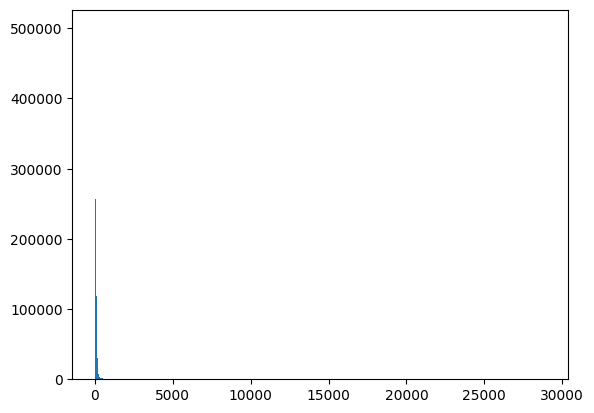

In [ ]:
# Amount
plt.hist(cc_train['amt'], bins=1000)
plt.show()
# outlier and right skewed



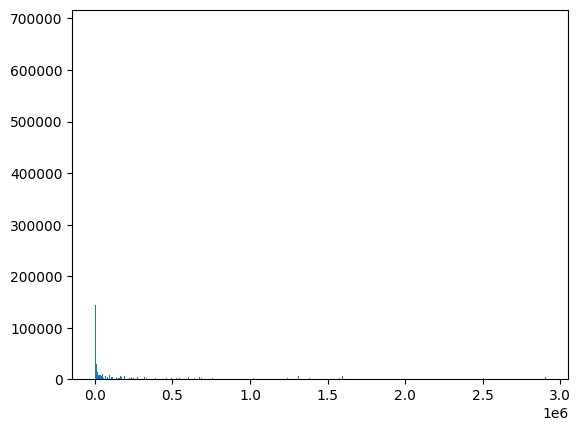

In [ ]:
# city population
plt.hist(cc_train['city_pop'], bins=1000)
plt.show()
# categorizing into village, town, city 

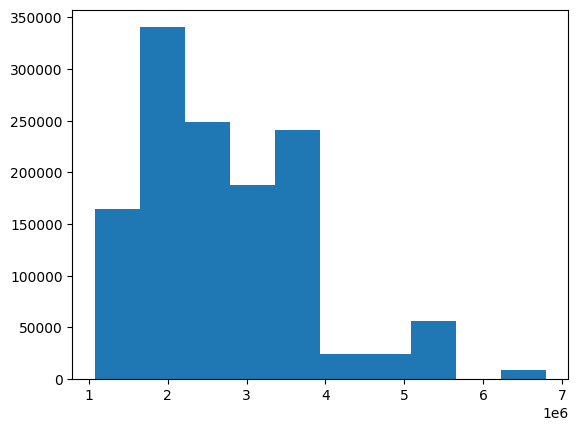

In [19]:
# categorical variables and their shares within the dataset
# 
plt.hist(cc_train['State_Risk_Rating'], bins=10)
plt.show()

 IN VAE - but deletion because of different approach
 Pipeline Description (from the paper)

1) At first the automatic feature extraction is conducted, select the most important features, form integrated embeddings, and preprocess the data.

2) 

## Using DASK
Change Code for performance

## Feature Engineering

Since some feature should be considered together, as input into the model are the engineered features instead of the original variables used.

Considering longitude and latitude in combination (both vor the victim, as well as for the merchant) results in information about the distance, whereas only each variable on their own is not sufficent.

Furthermore it is also reducing the dimensionality, by using less input variables within the model.

In [ ]:
# https://benfeifke.com/posts/feature-engineering-with-latitude-and-longitude/


In [4]:
from geopy.distance import distance, geodesic, great_circle

I.1) Engineered Feature 
Constructing a Risk Rating of each state by using FBI Data on Fraud occurence. If there are states in which due to governmental reasons, like regulation or technical infrasturcture. This feature might be an exogenous variable on our fraud flag. 

In [22]:
# combining States (governmental reasons) and their fraud losses/per Capita (extra dataset) as Risk-Rating Variable
# State_Risk_Rating
cc_train['State_Risk_Rating'] = cc_train['state'].map(crime_data.set_index('State_ID')['Loss in $/Capita'])


I.2) Engineered Feature
Using the geolocation data, to check if the adress of the client/victim and the merchant is distant. It might indicate either travelling or online shopping, but also suspicous behaviour. An card usage abroad in south east asia, which did not happen before could be at least suspicous, contacting a client and asking for current travel could be a safety feature.


In [5]:
# Using client and merchant distance, rowwise

cc_train['dist_client_merchant'] = cc_train.apply(
    lambda row: distance((row['lat'], row['long']), (row['merch_lat'], row['merch_long'])).km,
    axis=1
)

I.3) Engineered Feature
This feature is measering the distance of the previous card transaction to the current card transaction in relation to time. Even though due to travel or online shopping, this information does not tell for sure any fraudulent behaviour, but it shows some unusual behaviour, which is at least an indicator. In comparison to the second feature it is a more complex, but also more causal.

In [ ]:
# transforming str dtype int dateformat
cc_train['trans_date_trans_time']=pd.to_datetime(cc_train['trans_date_trans_time'])

In [ ]:
# Using merchant distance and time between transactions for each card
#cc_train['trans_time_dist'] = 
cc_train = cc_train.sort_values(['cc_num', 'trans_date_trans_time'])

# creating lagged values, for same card 
cc_train['prev_merch_lat']  = cc_train.groupby('cc_num')['merch_lat'].shift(1)
cc_train['prev_merch_long'] = cc_train.groupby('cc_num')['merch_long'].shift(1)
cc_train['prev_trans_time'] = cc_train.groupby('cc_num')['trans_date_trans_time'].shift(1)

# distance in km, per transaction
cc_train['dist_prev_current_trans'] = cc_train.apply(
    lambda row: distance(
        (row['merch_lat'], row['merch_long']), 
        (row['prev_merch_lat'], row['prev_merch_long']) 
    ).km if pd.notna(row['prev_merch_lat']) else 0,        # here else = 0 for non existing previous trans
    axis=1
)

# taking this into relation with time 
# Therefore time difference of transactions -> maybe feature on its own?
cc_train['trans_time_diff'] = cc_train.apply(
    lambda row: (row['trans_date_trans_time'] - row['prev_trans_time']).total_secondes() #secundes?
    if pd.notna(row['prev_trans_time']) else 0,             # here else = 0 for non existing previous trans
    axis=1
) 

# travel time distance -> If physical card usage, great feature
cc_train['travel_time_km'] = cc_train.apply(
    lambda row: row['dist_prev_current_trans'] / row['trans_time_diff']
    if row['trans_time_diff'] > 0 else 0,                   # here else = 0 for non existing previous trans
    axis=1
)



(Dornadula & Geetha, 2019): "Firstly, we use clustering method to divide the cardholders into different clusters/groups based on their transaction amount, i.e., high, medium and low using range partitioning.  Using Sliding-Window method, we aggregate the transactions into respective groups, i.e., extract some features from window to find cardholder's behavioural patterns. Features like maximum amount, minimum amount of transaction, followed by the average amount in the window and even the time elapsed."

II.1) Feature Representation
TODO:
By using a ordinal range/categories for the variables,  it results in some better model performances. 
(Linear SVM, Logistic Regression) -Linear SVM for this data not used.
Whereas we will use the scaled integer values, for our tree based models. (XGBoost, LightGBM)  

The following Variables are therefore transformed:

- City Population
- State Risk Rating

Ordinal text variables:
Following the Lab4 - OrdinalEncoder will be used from the preprocessing module in Scikit-learn. 

### Encoding

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()
cc_train['State_Risk_Rating_labels'] = encoder.fit_transform(cc_train[['State_Risk_Rating']]) # usefull transformation?
# category variable, with ordinal value the State Risk Rating etc...




In [25]:
from sklearn.preprocessing import OneHotEncoder
# No order between categories and smaller then 50, preclustering....
encoder = OneHotEncoder()
cc_train[['gender_label']] = encoder.fit_transform(cc_train[['gender']]) # gender

cc_train[['category_label']] = encoder.fit_transform(cc_train[['category']])

In [10]:
import category_encoders as ce
encoder = ce.CountEncoder(cols=['job'], normalize=False)
cc_train['job_freq'] = encoder.fit_transform(cc_train['job'])


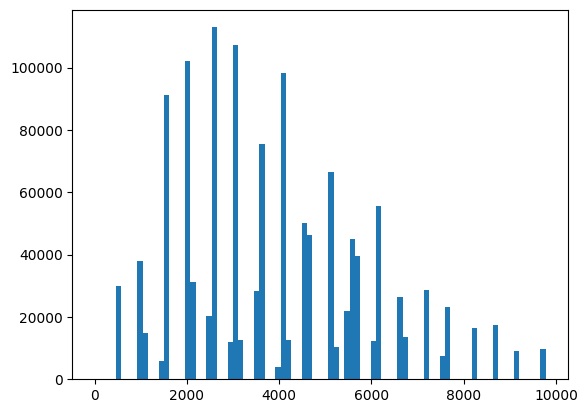

In [18]:

plt.hist(cc_train['job_freq'], bins=85)
plt.show()

In [ ]:
"""
frequency encoding 
ountEncoder	Replaces each merchant category with the number of times it appears in the dataset. This is excellent for capturing popularity 
(e.g., "McDonald's" might get a high score)

or 

Target Encoding	TargetEncoder	Replaces a merchant category with the average value of the target variable 
(e.g., average transaction amount or fraud rate) for that merchant. 
This can create powerful, predictive features 

"""

## Descriptive Data 

In [ ]:
# frquency encoding

## Scaling and Transforming Data

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler


scaler_MMS = MinMaxScaler(feature_range=(-1, 1))
src_bytes_scaled = scaler_MMS.fit_transform(data[['']])

scaler_SS = StandardScaler()
dst_bytes_scaled = scaler_SS.fit_transform(data[['']])

### Transformation 


#### Explanation
Square Root Transformation sqrt(x): 

                - Poisson-like data: as mean increases, variance increases linearly
                - Data containing zeros allowed
                - Compresses large values more than small ones, reduces right skew, stabilizes variance

Logarithmic Transform (y = ln(x) or log10(x)):

                - Strongly right-skewed positive! data
                - Multiplicative relationships → becomes additive (e.g., y = a * x^b becomes linear in log-log space).
                - NO! zeros or negative values (log(x+1) for 0s)

Inverse (Reciprocal) Transform (y = 1/x):

                - Very heavy right skew
                - Stabilizing variance when variance ∝ mean^4.
                - Reverses order (large values become small, small become large). Flattens extreme outliers!
                - Very sensitive to small values near! zero; NO! zeros (division by zero).

Exponential Transform (y = exp(x)):

                - makes right skew worse!!
                - It is useful as an inverse transform after fitting a model on log scale (e.g., after ln(y) = a + bx, you predict exp(a+bx) to return to original units)!!!

Box-Cox Transform (y = (x^λ - 1)/λ for λ ≠ 0, ln(x) for λ = 0):

                - Best systematic, data-driven choice if none transformation above fits best!
                - make data more normal (reduce skew, make symmetric)
                - To stabilize variance across the range of the data.
                - Requires positive data (for λ negative or fractional, negative x fails; but some extensions handle negative values).
                    How to choose λ:
                        λ = 1 → no change (data already normal)
                        λ = 0.5 → square root
                        λ = 0 → log
                        λ = -1 → inverse
                        λ = 0.33 → cube root

In [6]:
# frequency encoding
cc_train['job'] = cc_train['job'].astype('category').value_counts() 
cc_train['job_freq_encoded'] = cc_train['job'].map('freq')

TypeError: 'str' object is not callable

In [ ]:

# Population Categories

#cc_train['category'] # merchant category
cc_train['category'].value_counts().plot(kind='bar', color='blue', edgecolor='black')
plt.title('Transaction Numbers by Merchant Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()
plt.close()

# Too much jobs - How to handle?
# frequency encoding
#cc_train['jobs']
cc_train['job_freq_encoded'] = cc_train['job'].map(cc_train['job'].value_counts())
cc_train['job_freq_encoded'].plot(kind='bar', color='blue', edgecolor='black')
plt.title('Job frequency (encoded) by CC holder for the sum of transactions')
plt.xlabel('Job Frequency')
plt.ylabel('Count')
plt.show()
plt.close()

In [ ]:
# Input data 

# merchant long_lat
# client long_lat
# state_Risk_rating
# trans_action_date_time
# merchand category
# amount, amt
# cc 
# owner
# job 
# city population

## Feature selection via LightGBM

S. Shi et al. (2025): "We apply LightGBM [18] as the tool to conduct an #automatic feature selection process.
LightGBM, developed by Microsoft in 2017, is a tree-based gradient-
boosting framework. Its most extraordinary advantages are efficiency
and distributed computing. There are built-in functions that can calculate feature importance
scores automatically and visualize the sortation of importance."

package: https://lightgbm.readthedocs.io/en/latest/Python-Intro.html#training

In [6]:
import lightgbm as lgb

## XGBoost as second alternative approach for LightGBM?

## Plain Vanilla Variational-Autoencoder (VAE)

S. Shi et al. (2025, p.3): "VAE is a neural network architecture to generate synthetic samples.
It applies sufficient and explicit regularization in the latent space compared with conventional Autoencoders. [...]
The core components of VAE are an encoder and a decoder. The encoder obtains input data and transforms them into dense repre-
sentations while the decoder converts the representations back into original forms with minimization of loss.[...] The whole structure embodies the dimension reduction principles and generative capabilities of a neural network. The vital procedure of
this method is to figure out a proper latent layer to approximate the original distribution."

### Training steps of a typical VAE

S. Shi et al. (2025, p.3): 
• It encodes inputs as distribution rather than points.
• We sample a point of the latent space from that distribution.
• The latent layer performs regularization.
• We decode the sampled point and calculate the reconstruction loss.
• The reconstruction loss is backpropagated through the network and the overall method loss is minimized.

Loss function which will be used:

Loss = Reconstruction_Loss (MSE or Binary Cross-Entropy) + KL_Divergence


## CODE in comparison 

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Simple XGBoost
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2) # change here

model = xgb.XGBClassifier(
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1])
) # Why this scaling?
model.fit(X_train, y_train)
predictions = model.predict(X_test)

# Simple LightGBM
import lightgbm as lgb

model = lgb.LGBMClassifier(
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1])
)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

## Conclusion

Due to the lack of some information, there are considerations about the evaluation of the usage of geospatial data:

- There is no information, if the fraudulent transactions are conducted via
    A) Online purchases
    B) Physical usage 
    C) Or a mixture of both fraudulent activtities

Neither are any information about how the credit card data is lost to scammers. This could also via the mentioned type A,B,C. 

-> This has direct interpretation emphasizes, how to use the geospatial data efficiently.

CC information theft by physically reading the data via a modified terminal and then using those cards by the same scammer, would make the feature
    -  of distance between client and merchand relevant, in that case that small differences would be affecting the fraudulent usage.
    -  Online usage by scammers would make it, in the opposite direction relevant.



# Bibliography 

(contained in the zip file)

Dornadula, V. N., & Geetha, S. (2019). Credit Card Fraud Detection using Machine Learning Algorithms. Procedia Computer Science, 165, 631–641. https://doi.org/10.1016/j.procs.2020.01.057

Shi, S., Luo, W., & Pau, G. (2025). An attention-based balanced variational autoencoder method for credit card fraud detection. Applied Soft Computing, 177, 113190. https://doi.org/10.1016/j.asoc.2025.113190


